In [1]:
# ============================================================
# SECTION 0 — Setup
# ============================================================

%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

YEAR = "2014"

OUTPUT_DIR = PROJECT_ROOT / "outputs" / YEAR
save_files = False
debug= True
if debug:
    print("PROJECT_ROOT:", PROJECT_ROOT)
    print("OUTPUT_DIR:", OUTPUT_DIR)

PROJECT_ROOT: /mnt/data/jhub/16-VenusExpres/dsn_multi_year
OUTPUT_DIR: /mnt/data/jhub/16-VenusExpres/dsn_multi_year/outputs/2014


In [2]:
# ============================================================
# SECTION 1 — Final detection settings
# ============================================================

TRANSIENT_THRESHOLD = 3.0

MIN_CONSEC_WINDOWS = 2
MIN_DURATION_HR = 0.33
MAX_DURATION_HR = 12.0

MERGE_GAP_HR = 0.67

INPUT_FILE = OUTPUT_DIR / f"phase_windows_detected_{YEAR}.csv"
OUTPUT_FILE = OUTPUT_DIR / f"final_cme_candidates_{YEAR}.csv"
if debug:
    print("INPUT_FILE:", INPUT_FILE)
    print("OUTPUT_FILE:", OUTPUT_FILE)

INPUT_FILE: /mnt/data/jhub/16-VenusExpres/dsn_multi_year/outputs/2014/phase_windows_detected_2014.csv
OUTPUT_FILE: /mnt/data/jhub/16-VenusExpres/dsn_multi_year/outputs/2014/final_cme_candidates_2014.csv


In [3]:
# ============================================================
# SECTION 2 — Load CIR-removed DSN window table
# ============================================================

windows_df = pd.read_csv(INPUT_FILE)

for col in ["start", "end", "mid"]:
    windows_df[col] = pd.to_datetime(windows_df[col], errors="coerce")

windows_df = windows_df.sort_values("mid").reset_index(drop=True)

required_cols = [
    "start",
    "end",
    "mid",
    "phase_rms_rad",
    "clean_signal",
]

missing = [c for c in required_cols if c not in windows_df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")
if debug:
    print("Rows:", len(windows_df))
    print("Time range:", windows_df["mid"].min(), "→", windows_df["mid"].max())
    print("Clean signal range:", windows_df["clean_signal"].min(), "→", windows_df["clean_signal"].max())
    
    display(windows_df.head())

Rows: 4512
Time range: 2014-01-01 10:17:50 → 2014-06-04 16:47:50
Clean signal range: 0.1189496550575467 → 12.830325227853027


,start,end,mid,phase_rms_rad,n_samples,day,elongation_deg,phase_expected,phase_ratio,phase_smooth,clean_signal,event_flag
0,2014-01-01 10:07:50,2014-01-01 10:27:50,2014-01-01 10:17:50,2.297264,120,2014-01-01,16.6007,0.346279,6.634133,1.233473,5.378420,True
1,2014-01-01 10:17:50,2014-01-01 10:37:50,2014-01-01 10:27:50,1.239110,120,2014-01-01,16.6007,0.346279,3.578352,1.200665,2.980310,False
2,2014-01-01 10:27:50,2014-01-01 10:47:50,2014-01-01 10:37:50,0.465645,120,2014-01-01,16.6007,0.346279,1.344709,1.172485,1.146888,False
3,2014-01-01 10:37:50,2014-01-01 10:57:50,2014-01-01 10:47:50,0.378426,120,2014-01-01,16.6007,0.346279,1.092836,1.144305,0.955021,False
4,2014-01-01 10:47:50,2014-01-01 11:07:50,2014-01-01 10:57:50,0.673374,120,2014-01-01,16.6007,0.346279,1.944598,1.172485,1.658527,False


Candidates are defined as intervals where the CIR-removed clean signal exceeds
a threshold of 3.0 for at least two consecutive 20-minute windows.

Nearby candidates separated by less than 0.67 hr are merged into single events.

In [4]:
# ============================================================
# SECTION 3 — Detect short transient excesses
# ============================================================

w = windows_df.copy().sort_values("mid").reset_index(drop=True)

w["candidate"] = w["clean_signal"] > TRANSIENT_THRESHOLD

events = []
in_event = False

for i in range(len(w)):
    row = w.loc[i]

    if row["candidate"] and not in_event:
        start_idx = i
        in_event = True

    if in_event:
        is_last = i == len(w) - 1
        next_off = (not is_last) and (not w.loc[i + 1, "candidate"])

        if is_last or next_off:
            end_idx = i
            sub = w.loc[start_idx:end_idx].copy()

            duration_hr = (
                sub["end"].max() - sub["start"].min()
            ).total_seconds() / 3600.0

            if (
                len(sub) >= MIN_CONSEC_WINDOWS
                and duration_hr >= MIN_DURATION_HR
                and duration_hr <= MAX_DURATION_HR
            ):
                events.append({
                    "start": sub["start"].min(),
                    "end": sub["end"].max(),
                    "mid": sub["mid"].median(),
                    "duration_hr": duration_hr,
                    "n_windows": len(sub),
                    "peak_clean_signal": sub["clean_signal"].max(),
                    "median_clean_signal": sub["clean_signal"].median(),
                    "peak_phase_rms_rad": sub["phase_rms_rad"].max(),
                    "median_phase_rms_rad": sub["phase_rms_rad"].median(),
                })

            in_event = False

events_df = pd.DataFrame(events)
if debug:
    print("Initial events:", len(events_df))
    display(events_df.head())

Initial events: 10


,start,end,mid,duration_hr,n_windows,peak_clean_signal,median_clean_signal,peak_phase_rms_rad,median_phase_rms_rad
0,2014-01-02 10:07:50,2014-01-02 10:37:50,2014-01-02 10:22:50,0.5,2,5.935752,4.660562,2.339155,1.836629
1,2014-01-08 09:57:50,2014-01-08 10:27:50,2014-01-08 10:12:50,0.5,2,3.282327,3.164601,1.113386,1.049763
2,2014-01-24 10:47:50,2014-01-24 11:17:50,2014-01-24 11:02:50,0.5,2,4.354571,4.070721,1.874883,1.752670
3,2014-02-01 08:07:50,2014-02-01 08:37:50,2014-02-01 08:22:50,0.5,2,3.591409,3.358163,1.867863,1.756761
4,2014-02-03 06:47:50,2014-02-03 07:17:50,2014-02-03 07:02:50,0.5,2,5.993302,4.643548,2.427390,1.855042


In [5]:
# ============================================================
# SECTION 4 — Merge nearby candidates
# ============================================================

if events_df.empty:
    final_events = events_df.copy()

else:
    events_df = events_df.sort_values("start").reset_index(drop=True)

    merged = []
    current = events_df.iloc[0].copy()

    for i in range(1, len(events_df)):
        nxt = events_df.iloc[i]

        gap_hr = (
            nxt["start"] - current["end"]
        ).total_seconds() / 3600.0

        if gap_hr <= MERGE_GAP_HR:
            current["end"] = nxt["end"]
            current["mid"] = current["start"] + (current["end"] - current["start"]) / 2
            current["duration_hr"] = (
                current["end"] - current["start"]
            ).total_seconds() / 3600.0

            current["n_windows"] += nxt["n_windows"]
            current["peak_clean_signal"] = max(current["peak_clean_signal"], nxt["peak_clean_signal"])
            current["median_clean_signal"] = np.nanmedian([
                current["median_clean_signal"],
                nxt["median_clean_signal"]
            ])
            current["peak_phase_rms_rad"] = max(current["peak_phase_rms_rad"], nxt["peak_phase_rms_rad"])
            current["median_phase_rms_rad"] = np.nanmedian([
                current["median_phase_rms_rad"],
                nxt["median_phase_rms_rad"]
            ])

        else:
            merged.append(current)
            current = nxt.copy()

    merged.append(current)

    final_events = pd.DataFrame(merged)

final_events = final_events.reset_index(drop=True)
final_events.insert(0, "event_id", np.arange(1, len(final_events) + 1))
final_events.insert(1, "year", YEAR)

if debug:
    print("Final CME-like candidates:", len(final_events))
    display(final_events)

Final CME-like candidates: 10


,event_id,year,start,end,mid,duration_hr,n_windows,peak_clean_signal,median_clean_signal,peak_phase_rms_rad,median_phase_rms_rad
0,1,2014,2014-01-02 10:07:50,2014-01-02 10:37:50,2014-01-02 10:22:50,0.500000,2,5.935752,4.660562,2.339155,1.836629
1,2,2014,2014-01-08 09:57:50,2014-01-08 10:27:50,2014-01-08 10:12:50,0.500000,2,3.282327,3.164601,1.113386,1.049763
2,3,2014,2014-01-24 10:47:50,2014-01-24 11:17:50,2014-01-24 11:02:50,0.500000,2,4.354571,4.070721,1.874883,1.752670
3,4,2014,2014-02-01 08:07:50,2014-02-01 08:37:50,2014-02-01 08:22:50,0.500000,2,3.591409,3.358163,1.867863,1.756761
4,5,2014,2014-02-03 06:47:50,2014-02-03 07:17:50,2014-02-03 07:02:50,0.500000,2,5.993302,4.643548,2.427390,1.855042
5,6,2014,2014-02-06 06:57:50,2014-02-06 07:27:50,2014-02-06 07:12:50,0.500000,2,3.619539,3.326862,2.731495,2.510626
6,7,2014,2014-02-23 09:37:50,2014-02-23 10:27:50,2014-02-23 10:02:50,0.833333,4,4.365627,3.992019,2.432699,2.224510
7,8,2014,2014-05-20 05:57:50,2014-05-20 06:57:50,2014-05-20 06:27:50,1.000000,5,6.099006,4.733654,3.392047,2.632687
8,9,2014,2014-05-21 05:17:50,2014-05-21 05:47:50,2014-05-21 05:32:50,0.500000,2,3.390417,3.345933,2.364521,2.333497
9,10,2014,2014-05-31 07:47:50,2014-05-31 08:17:50,2014-05-31 08:02:50,0.500000,2,12.830325,8.124334,22.227667,14.074856


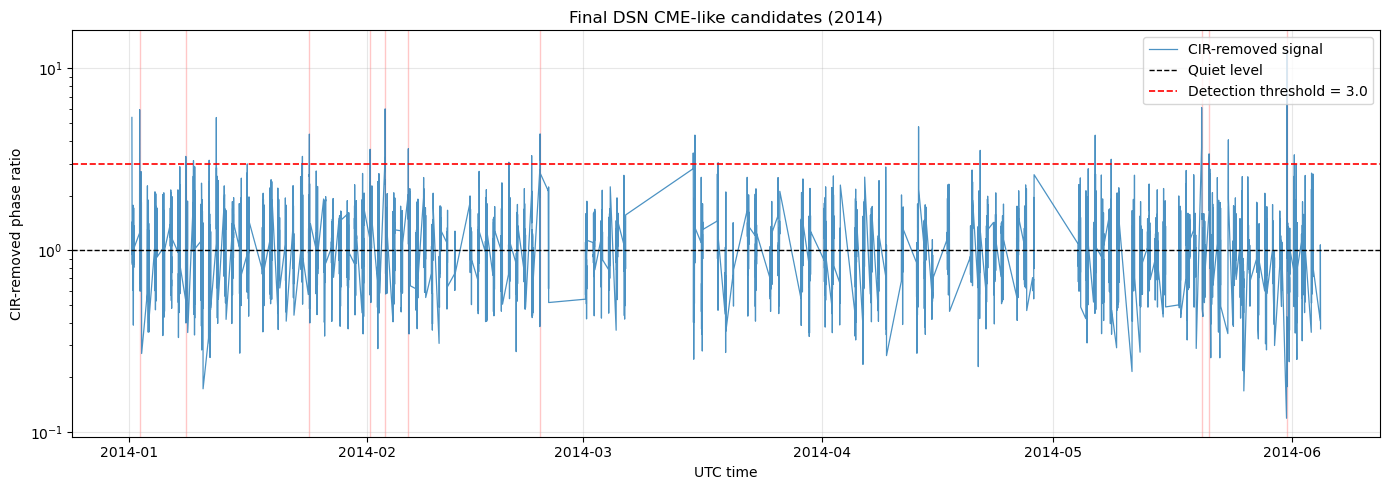

In [6]:
# ============================================================
# SECTION 5 — Plot final candidates
# ============================================================

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    w["mid"],
    w["clean_signal"],
    linewidth=0.9,
    alpha=0.8,
    label="CIR-removed signal"
)

ax.axhline(
    1.0,
    color="black",
    linestyle="--",
    linewidth=1,
    label="Quiet level"
)

ax.axhline(
    TRANSIENT_THRESHOLD,
    color="red",
    linestyle="--",
    linewidth=1.2,
    label=f"Detection threshold = {TRANSIENT_THRESHOLD}"
)

if not final_events.empty:
    for _, e in final_events.iterrows():
        ax.axvspan(e["start"], e["end"], color="red", alpha=0.22)

ax.set_yscale("log")
ax.set_xlabel("UTC time")
ax.set_ylabel("CIR-removed phase ratio")
ax.set_title(f"Final DSN CME-like candidates ({YEAR})")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

In [7]:
# ============================================================
# SECTION 6 — Candidate/background consistency diagnostics
# ============================================================

diagnostic_rows = []

for _, e in final_events.iterrows():

    event_mask = (
        (w["mid"] >= e["start"]) &
        (w["mid"] <= e["end"])
    )

    local_mask = (
        (w["mid"] >= e["start"] - pd.Timedelta(hours=12)) &
        (w["mid"] <= e["end"] + pd.Timedelta(hours=12))
    )

    background_mask = local_mask & ~event_mask

    evt = w.loc[event_mask]
    bg = w.loc[background_mask]

    if len(bg) == 0:
        bg_median = np.nan
        contrast = np.nan
    else:
        bg_median = bg["clean_signal"].median()
        contrast = evt["clean_signal"].median() / bg_median

    diagnostic_rows.append({
        "event_id": e["event_id"],
        "start": e["start"],
        "end": e["end"],
        "duration_hr": e["duration_hr"],
        "peak_clean_signal": e["peak_clean_signal"],
        "event_median_clean": evt["clean_signal"].median(),
        "local_background_median": bg_median,
        "contrast_ratio": contrast,
    })

diagnostics_df = pd.DataFrame(diagnostic_rows)

if debug:
    display(diagnostics_df.head(10))
    
    print("Median contrast ratio:", diagnostics_df["contrast_ratio"].median())
    print("Minimum contrast ratio:", diagnostics_df["contrast_ratio"].min())
    print("Maximum contrast ratio:", diagnostics_df["contrast_ratio"].max())

,event_id,start,end,duration_hr,peak_clean_signal,event_median_clean,local_background_median,contrast_ratio
0,1,2014-01-02 10:07:50,2014-01-02 10:37:50,0.500000,5.935752,3.015473,0.913393,3.301396
1,2,2014-01-08 09:57:50,2014-01-08 10:27:50,0.500000,3.282327,2.656232,0.941985,2.819825
2,3,2014-01-24 10:47:50,2014-01-24 11:17:50,0.500000,4.354571,3.167523,0.899459,3.521588
3,4,2014-02-01 08:07:50,2014-02-01 08:37:50,0.500000,3.591409,2.269744,1.048988,2.163746
4,5,2014-02-03 06:47:50,2014-02-03 07:17:50,0.500000,5.993302,3.293794,1.031786,3.192323
5,6,2014-02-06 06:57:50,2014-02-06 07:27:50,0.500000,3.619539,2.601751,1.036736,2.509560
6,7,2014-02-23 09:37:50,2014-02-23 10:27:50,0.833333,4.365627,3.525313,1.450730,2.430027
7,8,2014-05-20 05:57:50,2014-05-20 06:57:50,1.000000,6.099006,4.652974,0.908567,5.121221
8,9,2014-05-21 05:17:50,2014-05-21 05:47:50,0.500000,3.390417,2.978865,1.036469,2.874050
9,10,2014-05-31 07:47:50,2014-05-31 08:17:50,0.500000,12.830325,2.337511,0.969473,2.411115


Median contrast ratio: 2.8469373837942644
Minimum contrast ratio: 2.1637459758522084
Maximum contrast ratio: 5.121220954396783


In [8]:
# ============================================================
# SECTION 7 — Save candidate and diagnostic tables
# ============================================================

if save_files:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    final_events.to_csv(OUTPUT_FILE, index=False)

    diagnostics_file = OUTPUT_DIR / f"final_cme_candidate_diagnostics_{YEAR}.csv"
    diagnostics_df.to_csv(diagnostics_file, index=False)

    print("Saved candidate table:", OUTPUT_FILE)
    print("Saved diagnostics table:", diagnostics_file)

## CACTUS check


In [9]:
# ============================================================
# SECTION 0 — Setup
# ============================================================

%load_ext autoreload
%autoreload 2

import numpy as np
import sys
from pathlib import Path
import importlib

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import matplotlib.pyplot as plt


# ----------------------------------------
# Load year-specific settings dynamically
# ----------------------------------------
settings = importlib.import_module(f"config.settings_{YEAR}")

for k in dir(settings):
    if not k.startswith("_"):
        globals()[k] = getattr(settings, k)

# ----------------------------------------
# Imports
# ----------------------------------------
from src.geometry_utils import (
    load_horizons_los_geometry,
    add_los_p_point_geometry,
)

from src.detection_utils import (
    FinalCMEConfig,
    load_final_cme_input,
    detect_final_cme_candidates,
    compute_final_cme_contrast,
    add_event_median_columns,
    match_cactus_to_dsn_candidates,
)

from src.plot_utils import plot_final_cme_candidates
from src.io_utils import load_horizons_daily_sep

# ----------------------------------------
debug = True
sav_file = False

OUTPUT_DIR = PROJECT_ROOT / "outputs" / YEAR

print("YEAR:", YEAR)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("OUTPUT_DIR:", OUTPUT_DIR)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
YEAR: 2014
PROJECT_ROOT: /mnt/data/jhub/16-VenusExpres/dsn_multi_year
OUTPUT_DIR: /mnt/data/jhub/16-VenusExpres/dsn_multi_year/outputs/2014


In [10]:
# ============================================================
# SECTION 1 — Final CME-candidate settings
# ============================================================

final_cme_config = FinalCMEConfig(
    threshold=3.0,
    min_consec_windows=2,
    min_duration_hr=0.33,
    max_duration_hr=12.0,
    merge_gap_hr=0.67,
    local_background_hr=12.0,
)

INPUT_FILE = OUTPUT_DIR / f"phase_windows_detected_{YEAR}.csv"
OUTPUT_FILE = OUTPUT_DIR / f"final_cme_candidates_{YEAR}.csv"
CHECK_FILE = OUTPUT_DIR / f"final_cme_candidate_contrast_{YEAR}.csv"
FIG_FILE = OUTPUT_DIR / f"final_cme_candidates_{YEAR}.png"

if debug:
    print("INPUT_FILE:", INPUT_FILE)
    print("HORIZONS_FILE:", HORIZONS_FILE)
    print("OUTPUT_FILE:", OUTPUT_FILE)

INPUT_FILE: /mnt/data/jhub/16-VenusExpres/dsn_multi_year/outputs/2014/phase_windows_detected_2014.csv
HORIZONS_FILE: /mnt/data/jhub/16-VenusExpres/dsn_multi_year/inputs/2014_horizons.txt
OUTPUT_FILE: /mnt/data/jhub/16-VenusExpres/dsn_multi_year/outputs/2014/final_cme_candidates_2014.csv


In [11]:
# ============================================================
# SECTION 2 — Load CIR-removed DSN window table
# ============================================================

windows_df = load_final_cme_input(INPUT_FILE)

if debug:
    print("Rows:", len(windows_df))
    print("Time range:", windows_df["mid"].min(), "→", windows_df["mid"].max())
    print("Clean signal range:",
          windows_df["clean_signal"].min(),
          "→",
          windows_df["clean_signal"].max())
    display(windows_df.head())

Rows: 4512
Time range: 2014-01-01 10:17:50 → 2014-06-04 16:47:50
Clean signal range: 0.1189496550575467 → 12.830325227853027


,start,end,mid,phase_rms_rad,n_samples,day,elongation_deg,phase_expected,phase_ratio,phase_smooth,clean_signal,event_flag
0,2014-01-01 10:07:50,2014-01-01 10:27:50,2014-01-01 10:17:50,2.297264,120,2014-01-01,16.6007,0.346279,6.634133,1.233473,5.378420,True
1,2014-01-01 10:17:50,2014-01-01 10:37:50,2014-01-01 10:27:50,1.239110,120,2014-01-01,16.6007,0.346279,3.578352,1.200665,2.980310,False
2,2014-01-01 10:27:50,2014-01-01 10:47:50,2014-01-01 10:37:50,0.465645,120,2014-01-01,16.6007,0.346279,1.344709,1.172485,1.146888,False
3,2014-01-01 10:37:50,2014-01-01 10:57:50,2014-01-01 10:47:50,0.378426,120,2014-01-01,16.6007,0.346279,1.092836,1.144305,0.955021,False
4,2014-01-01 10:47:50,2014-01-01 11:07:50,2014-01-01 10:57:50,0.673374,120,2014-01-01,16.6007,0.346279,1.944598,1.172485,1.658527,False


In [12]:
# ============================================================
# SECTION 3 — Add LOS closest-approach geometry
# ============================================================

geom_daily = load_horizons_daily_sep(HORIZONS_FILE)

windows_df = add_los_p_point_geometry(
    windows_df,
    geom_daily,
    mid_col="mid",
    observer_sun_distance_AU=1.0,
)

if debug:
    print("Geometry rows:", len(geom_daily))
    print("SEP range:",
          windows_df["elongation_deg"].min(),
          "→",
          windows_df["elongation_deg"].max())
    print("P-point range AU:",
          windows_df["p_point_AU"].min(),
          "→",
          windows_df["p_point_AU"].max())

    display(
        windows_df[
            ["mid", "elongation_deg", "p_point_AU", "los_closest_from_earth_AU"]
        ].head()
    )

# ============================================================
# SECTION 3.5 — Add approximate P-point longitude
# ============================================================

# Use interpolated Venus heliocentric longitude from Horizons
# (assuming load_horizons_daily_sep can be extended or you already have
# hEcl_lon_deg in your geometry dataframe)

geom_full = load_horizons_los_geometry(HORIZONS_FILE)

geom = geom_full.set_index("day").sort_index()

windows_df["p_lon_deg"] = np.interp(
    windows_df["mid"].astype("int64"),
    geom.index.astype("int64"),
    geom["hEcl_lon_deg"]
)
if debug:
    print(
        windows_df["p_lon_deg"].min(),
        windows_df["p_lon_deg"].max()
    )
    
    display(
        windows_df[
            ["mid","p_point_AU","p_lon_deg"]
        ].head()
    )



Geometry rows: 365
SEP range: 5.134385821759259 → 46.550142523148146
P-point range AU: 0.0894920506895214 → 0.7259765081255857


,mid,elongation_deg,p_point_AU,los_closest_from_earth_AU
0,2014-01-01 10:17:50,16.009167,0.275791,0.961218
1,2014-01-01 10:27:50,15.999593,0.275631,0.961264
2,2014-01-01 10:37:50,15.990019,0.275470,0.961310
3,2014-01-01 10:47:50,15.980445,0.275309,0.961356
4,2014-01-01 10:57:50,15.970870,0.275149,0.961402


-17.0 57.14976851851852


,mid,p_point_AU,p_lon_deg
0,2014-01-01 10:17:50,0.275791,13.280440
1,2014-01-01 10:27:50,0.275631,13.204051
2,2014-01-01 10:37:50,0.275470,13.127662
3,2014-01-01 10:47:50,0.275309,13.051273
4,2014-01-01 10:57:50,0.275149,12.974884


In [13]:
# ============================================================
# SECTION 4 — Detect final CME-like candidates
# ============================================================

windows_flagged, final_events = detect_final_cme_candidates(
    windows_df,
    year=YEAR,
    config=final_cme_config,
)
if debug:
    print("Final CME-like candidates:", len(final_events))
    display(final_events)

# ============================================================
# SECTION 4.5 — Add event-level geometry summaries
# ============================================================

final_events = add_event_median_columns(
    final_events,
    windows_df,
    columns=["p_lon_deg"],
)
if debug:
    display(
        final_events[
            ["event_id", "p_point_AU_median", "p_lon_deg_median"]
        ]
    )

Final CME-like candidates: 10


,event_id,year,start,end,mid,duration_hr,n_windows,peak_clean_signal,median_clean_signal,peak_phase_rms_rad,median_phase_rms_rad,elongation_deg_median,p_point_AU_median,earth_sun_AU_median,los_closest_from_earth_AU_median
0,1,2014,2014-01-02 10:07:50,2014-01-02 10:37:50,2014-01-02 10:22:50,0.500000,2,5.935752,4.660562,2.339155,1.836629,14.619365,0.252396,1.0,0.967624
1,2,2014,2014-01-08 09:57:50,2014-01-08 10:27:50,2014-01-08 10:12:50,0.500000,2,3.282327,3.164601,1.113386,1.049763,6.707169,0.116795,1.0,0.993156
2,3,2014,2014-01-24 10:47:50,2014-01-24 11:17:50,2014-01-24 11:02:50,0.500000,2,4.354571,4.070721,1.874883,1.752670,20.784303,0.354851,1.0,0.934923
3,4,2014,2014-02-01 08:07:50,2014-02-01 08:37:50,2014-02-01 08:22:50,0.500000,2,3.591409,3.358163,1.867863,1.756761,29.562397,0.493371,1.0,0.869819
4,5,2014,2014-02-03 06:47:50,2014-02-03 07:17:50,2014-02-03 07:02:50,0.500000,2,5.993302,4.643548,2.427390,1.855042,31.357587,0.520378,1.0,0.853936
5,6,2014,2014-02-06 06:57:50,2014-02-06 07:27:50,2014-02-06 07:12:50,0.500000,2,3.619539,3.326862,2.731495,2.510626,33.857686,0.557132,1.0,0.830424
6,7,2014,2014-02-23 09:37:50,2014-02-23 10:27:50,2014-02-23 10:02:50,0.833333,4,4.365627,3.992019,2.432699,2.224510,42.871121,0.680352,1.0,0.732886
7,8,2014,2014-05-20 05:57:50,2014-05-20 06:57:50,2014-05-20 06:27:50,1.000000,5,6.099006,4.733654,3.392047,2.632687,39.459085,0.635527,1.0,0.772079
8,9,2014,2014-05-21 05:17:50,2014-05-21 05:47:50,2014-05-21 05:32:50,0.500000,2,3.390417,3.345933,2.364521,2.333497,39.270128,0.632977,1.0,0.774170
9,10,2014,2014-05-31 07:47:50,2014-05-31 08:17:50,2014-05-31 08:02:50,0.500000,2,12.830325,8.124334,22.227667,14.074856,37.206318,0.604687,1.0,0.796463


,event_id,p_point_AU_median,p_lon_deg_median
0,1,0.252396,28.626157
1,2,0.116795,-17.000000
2,3,0.354851,51.539699
3,4,0.493371,54.698380
4,5,0.520378,40.767824
5,6,0.557132,-16.000000
6,7,0.680352,40.000000
7,8,0.635527,7.455208
8,9,0.632977,19.778356
9,10,0.604687,28.711921


In [14]:
# ============================================================
# SECTION 5 — CACTus catalogue consistency check
# ============================================================

CACTUS_FILE = PROJECT_ROOT / "inputs" / f"cactus_cmes_{YEAR}.csv"
cactus_df = pd.read_csv(CACTUS_FILE)

if "los_pa_deg_median" in final_events.columns:
    EVENT_ANGLE_COL = "los_pa_deg_median"
elif "p_lon_deg_median" in final_events.columns:
    EVENT_ANGLE_COL = "p_lon_deg_median"
else:
    EVENT_ANGLE_COL = None

final_events = match_cactus_to_dsn_candidates(
    final_events,
    cactus_df,
    p_col="p_point_AU_median",
    event_angle_col=EVENT_ANGLE_COL,
    radial_tolerance_AU=0.20,
    angle_tolerance_deg=15.0,
)
if debug:
    print("Using event angle column:", EVENT_ANGLE_COL)
    
    print("\nCACTus crossing counts:")
    print(final_events["cactus_crosses_p_point"].value_counts(dropna=False))
    
    print("\nCACTus direction consistency counts:")
    print(final_events["cactus_direction_consistent"].value_counts(dropna=False))
    
    display(final_events)

Using event angle column: p_lon_deg_median

CACTus crossing counts:
cactus_crosses_p_point
True     9
False    1
Name: count, dtype: int64

CACTus direction consistency counts:
cactus_direction_consistent
True     9
False    1
Name: count, dtype: int64


,event_id,year,start,end,mid,duration_hr,n_windows,peak_clean_signal,median_clean_signal,peak_phase_rms_rad,...,matched_cactus_launch_utc,matched_cactus_speed_kms,matched_cactus_pa_deg,matched_cactus_width_deg,matched_cactus_half_width_deg,cactus_predicted_distance_AU,cactus_radial_error_AU,event_angle_deg,cactus_angle_error_deg,cactus_angle_allowed_deg
0,1,2014,2014-01-02 10:07:50,2014-01-02 10:37:50,2014-01-02 10:22:50,0.500000,2,5.935752,4.660562,2.339155,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2014,2014-01-08 09:57:50,2014-01-08 10:27:50,2014-01-08 10:12:50,0.500000,2,3.282327,3.164601,1.113386,...,2014-01-05 18:48:00,144.0,325.0,20.0,10.0,0.219748,0.102953,-17.000000,18.000000,25.0
2,3,2014,2014-01-24 10:47:50,2014-01-24 11:17:50,2014-01-24 11:02:50,0.500000,2,4.354571,4.070721,1.874883,...,2014-01-22 21:24:00,312.0,44.0,66.0,33.0,0.282660,0.072191,51.539699,7.539699,48.0
3,4,2014,2014-02-01 08:07:50,2014-02-01 08:37:50,2014-02-01 08:22:50,0.500000,2,3.591409,3.358163,1.867863,...,2014-01-26 15:24:00,189.0,74.0,10.0,5.0,0.623014,0.129643,54.698380,19.301620,20.0
4,5,2014,2014-02-03 06:47:50,2014-02-03 07:17:50,2014-02-03 07:02:50,0.500000,2,5.993302,4.643548,2.427390,...,2014-02-01 07:36:00,405.0,37.0,28.0,14.0,0.462427,0.057951,40.767824,3.767824,29.0
5,6,2014,2014-02-06 06:57:50,2014-02-06 07:27:50,2014-02-06 07:12:50,0.500000,2,3.619539,3.326862,2.731495,...,2014-02-02 08:48:00,281.0,344.0,22.0,11.0,0.638439,0.081307,-16.000000,0.000000,26.0
6,7,2014,2014-02-23 09:37:50,2014-02-23 10:27:50,2014-02-23 10:02:50,0.833333,4,4.365627,3.992019,2.432699,...,2014-02-20 03:24:00,403.0,46.0,70.0,35.0,0.762721,0.082369,40.000000,6.000000,50.0
7,8,2014,2014-05-20 05:57:50,2014-05-20 06:57:50,2014-05-20 06:27:50,1.000000,5,6.099006,4.733654,3.392047,...,2014-05-12 16:12:00,159.0,359.0,8.0,4.0,0.697389,0.061862,7.455208,8.455208,19.0
8,9,2014,2014-05-21 05:17:50,2014-05-21 05:47:50,2014-05-21 05:32:50,0.500000,2,3.390417,3.345933,2.364521,...,2014-05-17 01:25:00,252.0,350.0,106.0,53.0,0.607217,0.025760,19.778356,29.778356,68.0
9,10,2014,2014-05-31 07:47:50,2014-05-31 08:17:50,2014-05-31 08:02:50,0.500000,2,12.830325,8.124334,22.227667,...,2014-05-25 23:24:00,150.0,18.0,18.0,9.0,0.464375,0.140312,28.711921,10.711921,24.0


In [15]:
# ============================================================
# SECTION 6 — Save DSN/CACTus-matched events for PRIDE notebook
# ============================================================

EVENTS_FOR_PRIDE_FILE = OUTPUT_DIR / f"dsn_cactus_events_for_pride_{YEAR}.csv"

cols_for_pride = [
    "event_id", "year", "start", "end", "mid", "duration_hr", "n_windows",
    "peak_clean_signal", "median_clean_signal", "peak_phase_rms_rad",
    "p_point_AU_median", "event_angle_deg",
    "cactus_crosses_p_point", "cactus_direction_consistent",
    "matched_cactus_launch_utc", "matched_cactus_speed_kms",
    "matched_cactus_pa_deg", "matched_cactus_width_deg",
    "cactus_predicted_distance_AU", "cactus_radial_error_AU",
    "cactus_angle_error_deg", "cactus_angle_allowed_deg",
]

cols_for_pride = [c for c in cols_for_pride if c in final_events.columns]

events_for_pride = final_events[cols_for_pride].copy()

events_for_pride.to_csv(EVENTS_FOR_PRIDE_FILE, index=False)

print("Saved:", EVENTS_FOR_PRIDE_FILE)
display(events_for_pride)

Saved: /mnt/data/jhub/16-VenusExpres/dsn_multi_year/outputs/2014/dsn_cactus_events_for_pride_2014.csv


,event_id,year,start,end,mid,duration_hr,n_windows,peak_clean_signal,median_clean_signal,peak_phase_rms_rad,...,cactus_crosses_p_point,cactus_direction_consistent,matched_cactus_launch_utc,matched_cactus_speed_kms,matched_cactus_pa_deg,matched_cactus_width_deg,cactus_predicted_distance_AU,cactus_radial_error_AU,cactus_angle_error_deg,cactus_angle_allowed_deg
0,1,2014,2014-01-02 10:07:50,2014-01-02 10:37:50,2014-01-02 10:22:50,0.500000,2,5.935752,4.660562,2.339155,...,False,False,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2014,2014-01-08 09:57:50,2014-01-08 10:27:50,2014-01-08 10:12:50,0.500000,2,3.282327,3.164601,1.113386,...,True,True,2014-01-05 18:48:00,144.0,325.0,20.0,0.219748,0.102953,18.000000,25.0
2,3,2014,2014-01-24 10:47:50,2014-01-24 11:17:50,2014-01-24 11:02:50,0.500000,2,4.354571,4.070721,1.874883,...,True,True,2014-01-22 21:24:00,312.0,44.0,66.0,0.282660,0.072191,7.539699,48.0
3,4,2014,2014-02-01 08:07:50,2014-02-01 08:37:50,2014-02-01 08:22:50,0.500000,2,3.591409,3.358163,1.867863,...,True,True,2014-01-26 15:24:00,189.0,74.0,10.0,0.623014,0.129643,19.301620,20.0
4,5,2014,2014-02-03 06:47:50,2014-02-03 07:17:50,2014-02-03 07:02:50,0.500000,2,5.993302,4.643548,2.427390,...,True,True,2014-02-01 07:36:00,405.0,37.0,28.0,0.462427,0.057951,3.767824,29.0
5,6,2014,2014-02-06 06:57:50,2014-02-06 07:27:50,2014-02-06 07:12:50,0.500000,2,3.619539,3.326862,2.731495,...,True,True,2014-02-02 08:48:00,281.0,344.0,22.0,0.638439,0.081307,0.000000,26.0
6,7,2014,2014-02-23 09:37:50,2014-02-23 10:27:50,2014-02-23 10:02:50,0.833333,4,4.365627,3.992019,2.432699,...,True,True,2014-02-20 03:24:00,403.0,46.0,70.0,0.762721,0.082369,6.000000,50.0
7,8,2014,2014-05-20 05:57:50,2014-05-20 06:57:50,2014-05-20 06:27:50,1.000000,5,6.099006,4.733654,3.392047,...,True,True,2014-05-12 16:12:00,159.0,359.0,8.0,0.697389,0.061862,8.455208,19.0
8,9,2014,2014-05-21 05:17:50,2014-05-21 05:47:50,2014-05-21 05:32:50,0.500000,2,3.390417,3.345933,2.364521,...,True,True,2014-05-17 01:25:00,252.0,350.0,106.0,0.607217,0.025760,29.778356,68.0
9,10,2014,2014-05-31 07:47:50,2014-05-31 08:17:50,2014-05-31 08:02:50,0.500000,2,12.830325,8.124334,22.227667,...,True,True,2014-05-25 23:24:00,150.0,18.0,18.0,0.464375,0.140312,10.711921,24.0


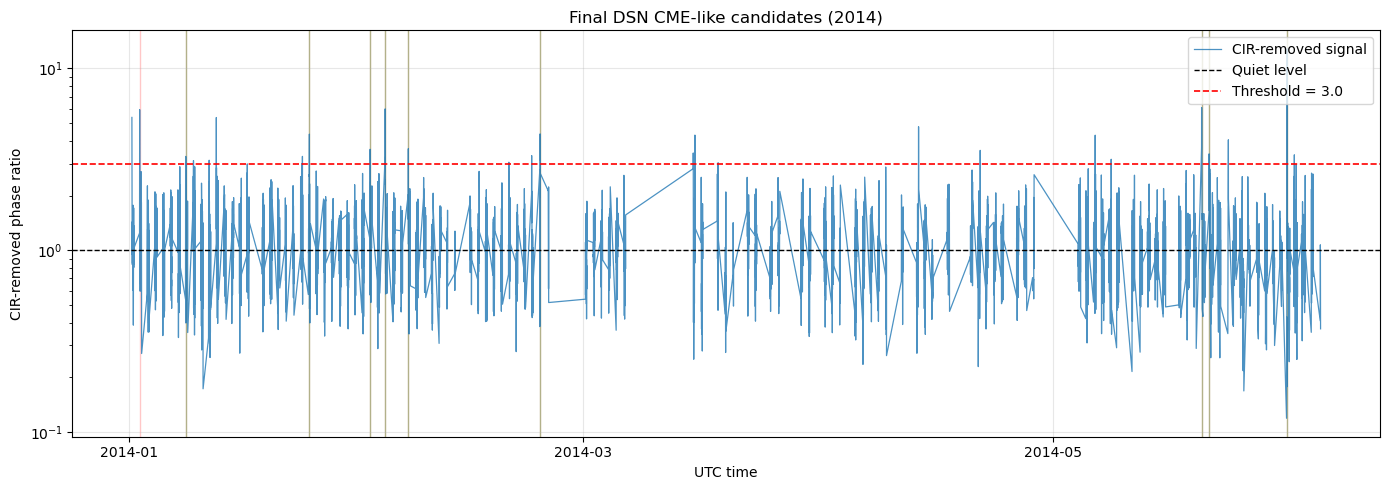

In [16]:
fig, ax = plot_final_cme_candidates(
    windows_flagged,
    final_events,
    year=YEAR,
)

# overlay supported events
for _, e in final_events.iterrows():
    if e["cactus_crosses_p_point"]:
        ax.axvspan(e["start"], e["end"], color="green", alpha=0.3)

plt.show()



Supported duration: 0.5
Unsupported duration: 0.5
Supported peak: 4.354571417315718
Unsupported peak: 5.935751928684949
Supported median signal: 3.9920189024694777
Unsupported median signal: 4.660562294332166


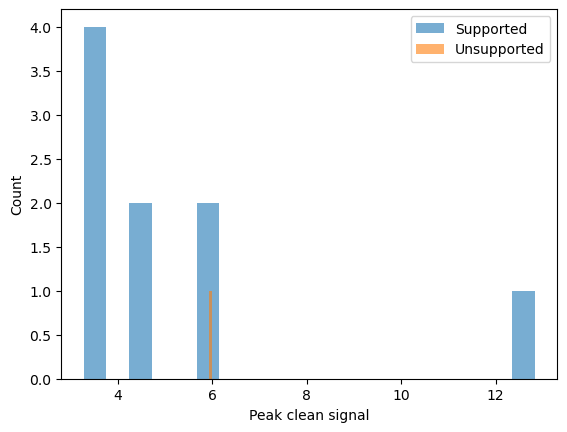

Supported contrast: 1.0879737180927953
Unsupported contrast: 1.273612829057896


In [17]:
supported = final_events[final_events["cactus_crosses_p_point"]]
unsupported = final_events[~final_events["cactus_crosses_p_point"]]

supported = final_events[final_events["cactus_crosses_p_point"] == True]
unsupported = final_events[final_events["cactus_crosses_p_point"] == False]

print("Supported duration:", supported["duration_hr"].median())
print("Unsupported duration:", unsupported["duration_hr"].median())
print("Supported peak:", supported["peak_clean_signal"].median())
print("Unsupported peak:", unsupported["peak_clean_signal"].median())
print("Supported median signal:", supported["median_clean_signal"].median())
print("Unsupported median signal:", unsupported["median_clean_signal"].median())
plt.hist(supported["peak_clean_signal"], bins=20, alpha=0.6, label="Supported")
plt.hist(unsupported["peak_clean_signal"], bins=20, alpha=0.6, label="Unsupported")
plt.legend()
plt.xlabel("Peak clean signal")
plt.ylabel("Count")
plt.show()

final_events["contrast"] = (
    final_events["peak_clean_signal"] /
    final_events["median_clean_signal"]
)

supported = final_events[final_events["cactus_crosses_p_point"] == True].copy()
unsupported = final_events[final_events["cactus_crosses_p_point"] == False].copy()

print("Supported contrast:", supported["contrast"].median())
print("Unsupported contrast:", unsupported["contrast"].median())